In [1]:
!pip install -q scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

In [5]:
url="https://raw.githubusercontent.com/AI-Learning-Repo/Data-Handling/refs/heads/week5/datasets/mall-customers.csv"

customers = pd.read_csv(url)

customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print(customers.shape)
print(customers.info())
print(customers.isna().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
feature_names = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X_df = customers[feature_names].dropna()
X = X_df.to_numpy()

In [8]:
print(X.shape)

(200, 2)


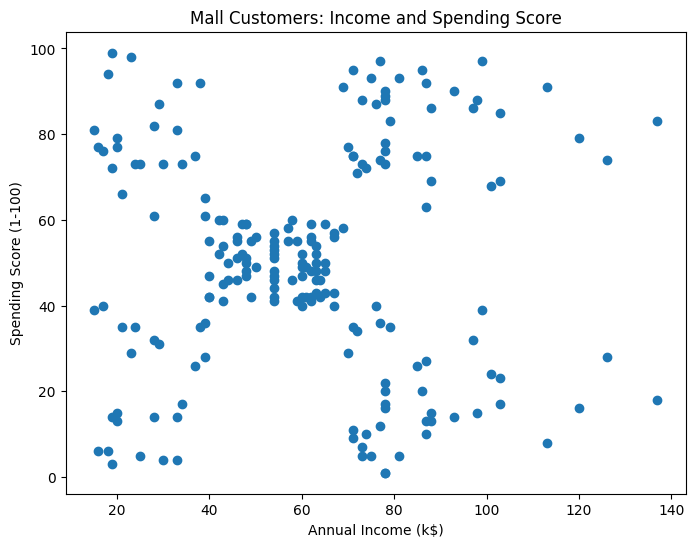

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customers: Income and Spending Score")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

In [11]:
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [12]:
labels = kmeans.labels_

print(labels[:20])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


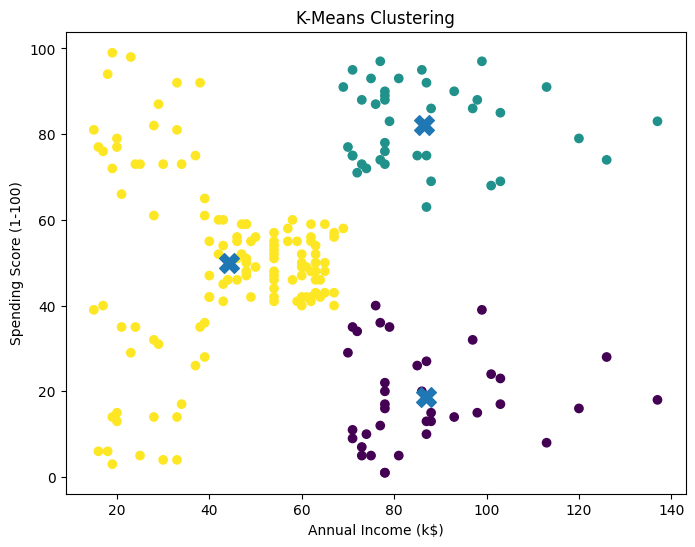

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering")

plt.show()

In [14]:
print(kmeans.cluster_centers_)

[[87.         18.63157895]
 [86.53846154 82.12820513]
 [44.15447154 49.82926829]]


In [15]:
KMeans(n_clusters=3)

KMeans(n_clusters=3)

In [16]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init="auto"
)

labels_2 = kmeans_2.fit_predict(X)

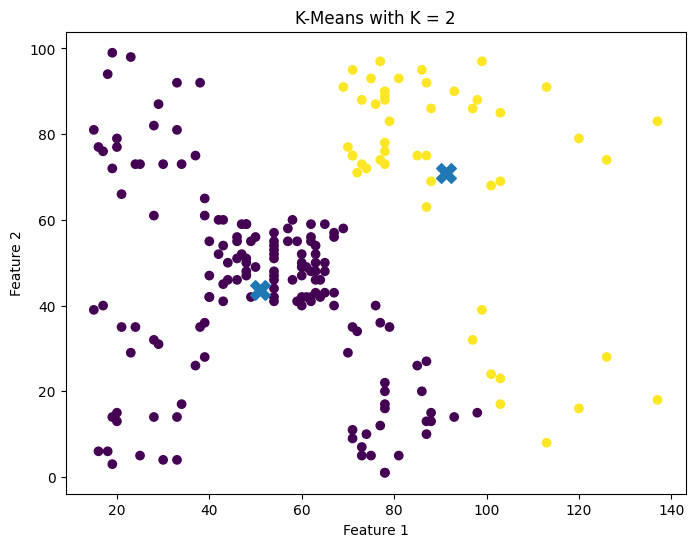

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_2
)

plt.scatter(
    kmeans_2.cluster_centers_[:, 0],
    kmeans_2.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means with K = 2")

plt.show()

In [18]:
hierarchical = AgglomerativeClustering(
    n_clusters=3
)

In [19]:
hierarchical_labels = hierarchical.fit_predict(X)

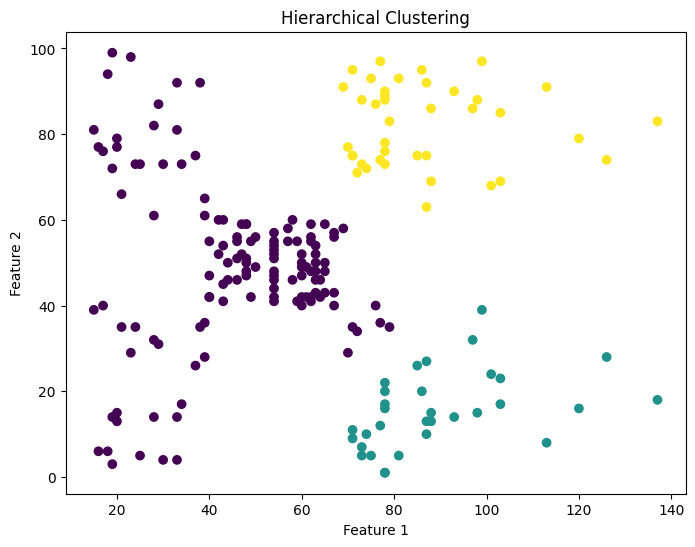

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=hierarchical_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering")

plt.show()

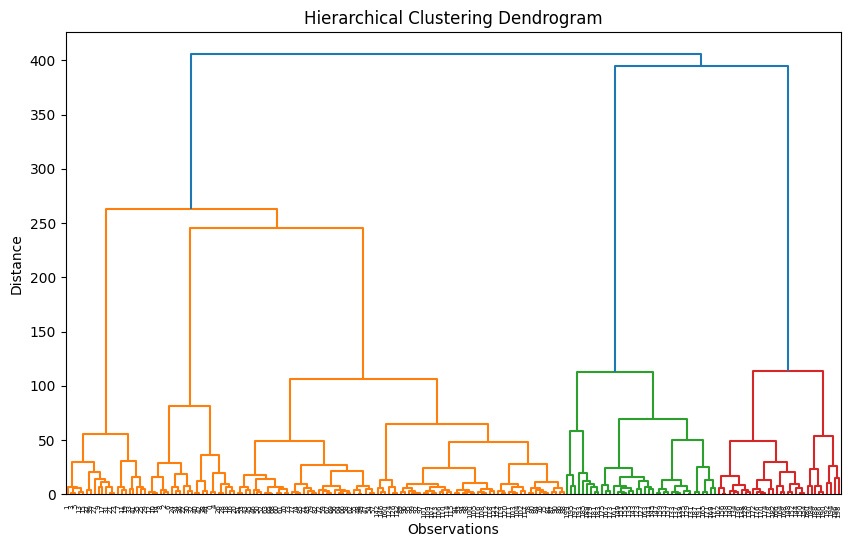

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [22]:
!pip install -q scipy

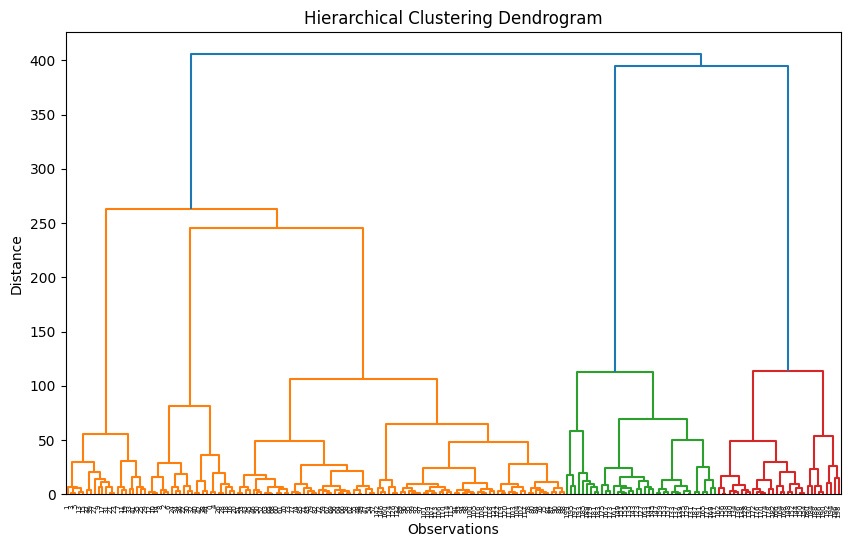

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
KMeans(n_clusters=3)

KMeans(n_clusters=3)

In [27]:
cluster_std=1.2

In [28]:
from sklearn.datasets import make_blobs

X_overlap, true_generation_labels = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=2.5,
    random_state=42
)

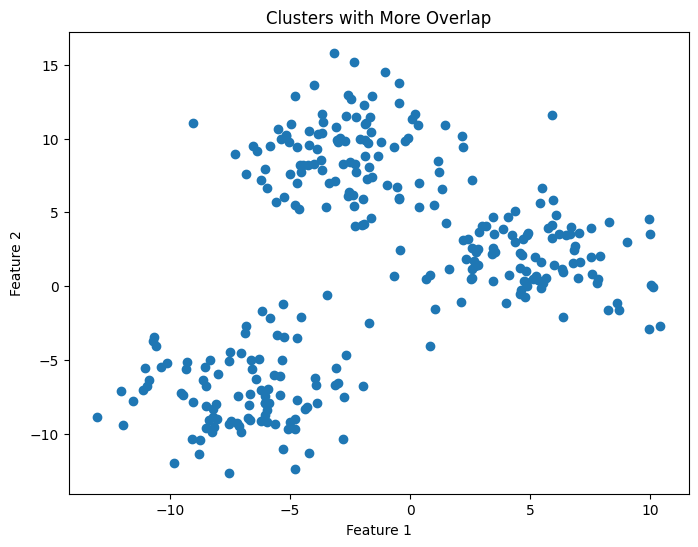

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_overlap[:, 0],
    X_overlap[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clusters with More Overlap")

plt.show()

In [30]:
kmeans_overlap = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

labels_overlap = kmeans_overlap.fit_predict(
    X_overlap
)

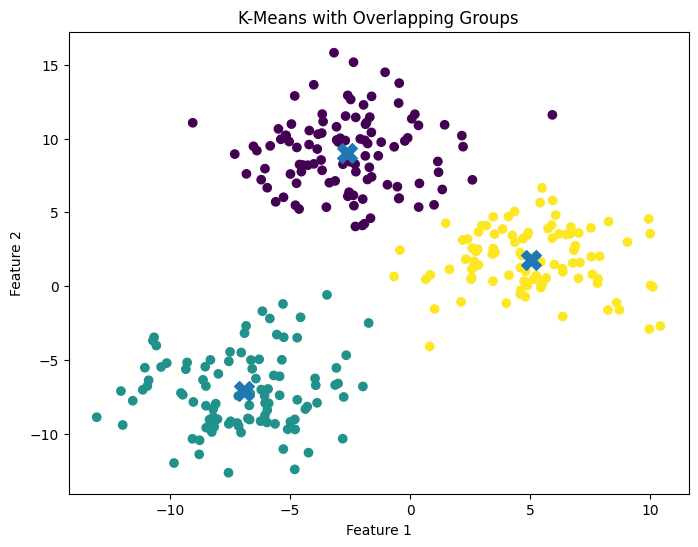

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_overlap[:, 0],
    X_overlap[:, 1],
    c=labels_overlap
)

plt.scatter(
    kmeans_overlap.cluster_centers_[:, 0],
    kmeans_overlap.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means with Overlapping Groups")

plt.show()

In [32]:
KMeans(n_clusters=5)

KMeans(n_clusters=5)

In [33]:
rng = np.random.default_rng(42)

X_random = rng.uniform(
    0,
    10,
    size=(300, 2)
)

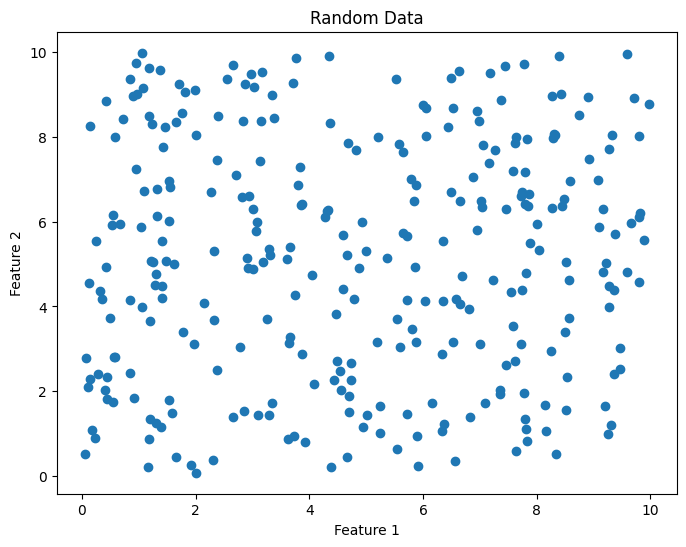

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_random[:, 0],
    X_random[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Random Data")

plt.show()

In [35]:
random_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

random_labels = random_kmeans.fit_predict(
    X_random
)